### Alunos
NATHAN CARDOSO LINHARES  2026010155

PEDRO VINICIUS DE ANDRADE QUEIROZ 2026010152     

Realizando o import do dataset. 

Disponível em: <a href="">archive.ics.uci.edu/ml/datasets/Wine+Quality</a>

In [2]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd

# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
# data (as pandas dataframes) 
X = wine_quality.data.features 
y = wine_quality.data.targets 
  
# Atributos físico-químicos
display(X)

# Rotulo de qualidade
display(y)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8


,quality
0,5
1,5
2,5
3,6
4,5
...,...
6492,6
6493,5
6494,6
6495,7


#### Questão 1

Aqui será realizada a recodificação da variável quality em três classes: 
* 'ruim' para nota <= 5; 
* 'medio' para 5 > nota <= 7;
* 'bom' para nota > 7

Em seguida será realizada a normalização dos dados. 
A etapa de normalização é essencial no k-NN por se tratar de um algoritmo dependente de distâncias, sendo sensível à escala dos atributos. Valores discrepantes na escala podem enviesar o algoritmo, fazendo com que variáveis em escalas maiores dominem o cálculo da distância e influenciem indevidamente o resultado.

In [3]:
from sklearn.preprocessing import MinMaxScaler

# Modificando o conjunto de dados de qualidade do vinho para as três classes sugeridas.
new_y = y['quality'].apply(
    lambda value: "ruim" if value <= 5
    else "medio" if value <= 7
    else "bom"
)

# Exibindo o conjunto com rotulos substituídos pelas três classes
display(new_y)

# Normalizando os demais dados com o MinMaxScaler
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

# Exibindo a normalização dos atributos
display(pd.DataFrame(X_normalized))

0        ruim
1        ruim
2        ruim
3       medio
4        ruim
        ...  
6492    medio
6493     ruim
6494    medio
6495    medio
6496    medio
Name: quality, Length: 6497, dtype: str

,0,1,2,3,4,5,6,7,8,9,10
0,0.297521,0.413333,0.000000,0.019939,0.111296,0.034722,0.064516,0.206092,0.612403,0.191011,0.202899
1,0.330579,0.533333,0.000000,0.030675,0.147841,0.083333,0.140553,0.186813,0.372093,0.258427,0.260870
2,0.330579,0.453333,0.024096,0.026074,0.137874,0.048611,0.110599,0.190669,0.418605,0.241573,0.260870
3,0.611570,0.133333,0.337349,0.019939,0.109635,0.055556,0.124424,0.209948,0.341085,0.202247,0.260870
4,0.297521,0.413333,0.000000,0.019939,0.111296,0.034722,0.064516,0.206092,0.612403,0.191011,0.202899
...,...,...,...,...,...,...,...,...,...,...,...
6492,0.198347,0.086667,0.174699,0.015337,0.049834,0.079861,0.198157,0.077694,0.426357,0.157303,0.463768
6493,0.231405,0.160000,0.216867,0.113497,0.063123,0.194444,0.373272,0.150183,0.333333,0.134831,0.231884
6494,0.223140,0.106667,0.114458,0.009202,0.053156,0.100694,0.241935,0.104685,0.209302,0.134831,0.202899
6495,0.140496,0.140000,0.180723,0.007669,0.021595,0.065972,0.239631,0.030461,0.480620,0.089888,0.695652


#### Questão 2

Divisão dos dados em grupos de treinamento e teste, com cada grupo contendo, respectivamente, 80% e 20% dos dados, utilizando divisão estratificada para garantir que a proporção das três classes seja mantida em ambos os conjuntos.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_normalized,
    new_y,
    test_size=0.2,
    stratify=new_y,
    random_state=42
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (5197, 11)
Teste: (1300, 11)


#### Questão 3

Treinamento do modelo com diferentes valores de k (1, 3, 5, 7 e 11) utilizando validação cruzada de 5 folds sobre o conjunto de treino.

In [5]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# Valores de k
k_values = [1, 3, 5, 7, 11]

mean_scores = []

# Teste dos valores de K
for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    # Validação cruzada com 5 folds
    scores = cross_val_score(
        knn,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    # Média da acurácia
    mean_scores.append(scores.mean())

    print(f"k = {k}")
    print(f"Acurácias: {scores}")
    print(f"Média: {scores.mean():.4f}")

# Melhor k
best_k = k_values[mean_scores.index(max(mean_scores))]

print(f"Melhor valor de k: {best_k}")


k = 1
Acurácias: [0.71923077 0.72211538 0.75553417 0.75264678 0.74975938]
Média: 0.7399
k = 3
Acurácias: [0.70096154 0.68942308 0.71318576 0.71607315 0.73243503]
Média: 0.7104
k = 5
Acurácias: [0.71730769 0.70865385 0.72569779 0.72281039 0.7333975 ]
Média: 0.7216
k = 7
Acurácias: [0.725      0.71346154 0.72088547 0.72954764 0.71799808]
Média: 0.7214
k = 11
Acurácias: [0.71826923 0.7125     0.72473532 0.72473532 0.72666025]
Média: 0.7214
Melhor valor de k: 1


Apesar do valor de k = 1 apresentar maior acurácia, essa escolha torna o modelo muito sensível aos dados, levando ao overfitting. Enquanto isso, valores como k = 7 ou k = 8 apresentam melhor desempenho e maior capacidade de generalização, sendo mais adequados para o modelo.

#### Questão 4

Avaliação do modelo e exibição das métricas de qualidade.

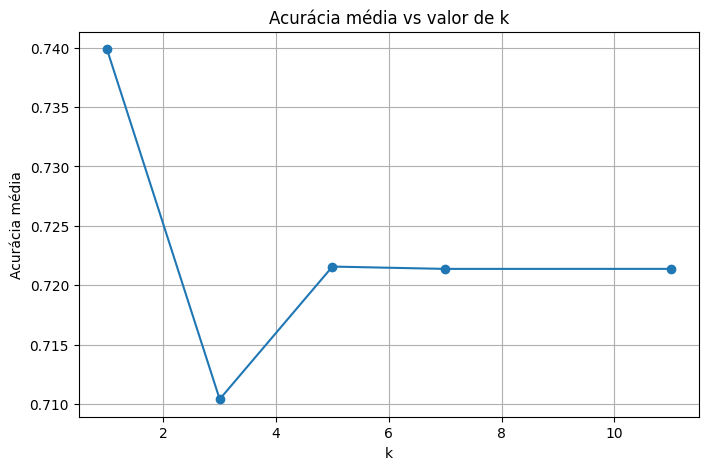

In [6]:
plt.figure(figsize=(8,5))
plt.plot(k_values, mean_scores, marker='o')
plt.title("Acurácia média vs valor de k")
plt.xlabel("k")
plt.ylabel("Acurácia média")
plt.grid(True)
plt.show()

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report
)

knn = KNeighborsClassifier(n_neighbors=best_k)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

print("\nMatriz de Confusão:\n")
print(confusion_matrix(y_test, y_pred))

Acurácia: 0.7607692307692308
              precision    recall  f1-score   support

         bom       0.48      0.50      0.49        40
       medio       0.80      0.80      0.80       783
        ruim       0.72      0.71      0.72       477

    accuracy                           0.76      1300
   macro avg       0.67      0.67      0.67      1300
weighted avg       0.76      0.76      0.76      1300


Matriz de Confusão:

[[ 20  20   0]
 [ 21 630 132]
 [  1 137 339]]


O modelo erra com mais frequência entre as classes médio e ruim, especialmente quando classifica exemplos da classe ruim como médio e exemplos da classe médio como ruim.